<a href="https://colab.research.google.com/github/Mariam-Elbishbeashy/HeadlineGeneration-NLP/blob/main/FLAN_T5_SMALL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **📰 FLAN-T5 News Headline Generation Project**

This project trains a FLAN-T5-Small transformer model to automatically generate news headlines from full articles.

The dataset contains:
- model_input  → full news article text
- model_target → correct headline

Main steps in this notebook:
1. Load dataset from Google Drive
2. Clean and sample data for fast training
3. Convert data into HuggingFace Dataset format
4. Load FLAN-T5-Small model and tokenizer
5. Tokenize input and output text
6. Train model using Seq2SeqTrainer
7. Save trained model to Google Drive
8. Test model with sample article input

Goal:
Learn how to convert long news articles into short, meaningful headlines using NLP and Transformers.

# 🧠 MODEL PIPELINE OVERVIEW (FLAN-T5 HEADLINE GENERATION)

## 1. Data Input
The model receives news articles as input (`model_input`) and their corresponding headlines (`model_target`) as targets.  
These are loaded from CSV files and prepared for training.

---

## 2. Model Setup
A pre-trained transformer model is used:

- Model: `google/flan-t5-small`
- Type: Sequence-to-sequence (text-to-text)
- Components:
  - Tokenizer → converts text into tokens
  - Model → learns mapping from article → headline

---

## 3. Input Formatting
Each article is formatted into a task prompt:

"summarize: <article text>"

This helps the model understand the task is summarization / headline generation.

---

## 4. Tokenization Process
- Input articles are tokenized into model-readable IDs
- Target headlines are also tokenized
- Both are converted into tensors for training

This allows the model to learn the relationship between:
Article → Short headline

---

## 5. Training Process
The model is trained using:

- Seq2SeqTrainer (Hugging Face)
- Mini-batch gradient updates
- Loss function optimization (cross-entropy)

The model gradually improves its ability to generate accurate headlines.

---

## 6. Optimization Settings
To make training fast and lightweight:

- Small batch size
- Limited sequence lengths
- 1 training epoch
- GPU/CPU auto-detection
- No heavy evaluation during training

---

## 7. Model Saving
After training:
- The fine-tuned model is saved to Google Drive
- Tokenizer is saved alongside it

This allows reuse without retraining.

---

## 8. Inference (Prediction)
For new articles:

1. Add prompt: "summarize: <article>"
2. Tokenize input
3. Model generates output using beam search
4. Tokens are decoded into a readable headline

---

## 9. Final Output
The system outputs:
👉 A generated news headline that summarizes the input article

In [1]:
# ============================================================
# FAST FLAN-T5-SMALL TRAINING FOR HEADLINE GENERATION
# CPU/GPU OPTIMIZED VERSION
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================

!pip install -q transformers datasets evaluate sentencepiece accelerate

# ============================================================
# 2. IMPORTS
# ============================================================

import os
import torch
import pandas as pd
import numpy as np

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq,
)

# ============================================================
# 3. CHECK DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print(f"DEVICE: {device}")
print("=" * 60)

# ============================================================
# 4. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# 5. DATA PATHS
# ============================================================

DATA_DIR = "/content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data"

TRAIN_PATH = os.path.join(DATA_DIR, "flan_t5_small_train.csv")
VAL_PATH = os.path.join(DATA_DIR, "flan_t5_small_validation.csv")
TEST_PATH = os.path.join(DATA_DIR, "flan_t5_small_test.csv")

# ============================================================
# 6. LOAD DATASETS
# ============================================================

print("=" * 60)
print("Loading datasets...")
print("=" * 60)

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

# ============================================================
# 7. USE SMALLER DATA FOR FAST TRAINING
# ============================================================

train_df = train_df.sample(5000, random_state=42)
val_df = val_df.sample(1000, random_state=42)
test_df = test_df.sample(1000, random_state=42)

print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# ============================================================
# 8. KEEP REQUIRED COLUMNS
# ============================================================

train_df = train_df[["model_input", "model_target"]]
val_df = val_df[["model_input", "model_target"]]
test_df = test_df[["model_input", "model_target"]]

# ============================================================
# 9. CONVERT TO HF DATASET
# ============================================================

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# ============================================================
# 10. LOAD MODEL + TOKENIZER
# ============================================================

MODEL_NAME = "google/flan-t5-small"

print("=" * 60)
print(f"Loading model: {MODEL_NAME}")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

model.to(device)

# ============================================================
# 11. FAST SETTINGS
# ============================================================

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 32

# ============================================================
# 12. TOKENIZATION FUNCTION
# ============================================================

def preprocess_function(examples):

    inputs = [
        f"summarize: {text}"
        for text in examples["model_input"]
    ]

    targets = examples["model_target"]

    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
    )

    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

# ============================================================
# 13. TOKENIZE DATASETS
# ============================================================

print("=" * 60)
print("Tokenizing datasets...")
print("=" * 60)

tokenized_train = train_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=1000,
    remove_columns=train_dataset.column_names,
)

tokenized_val = val_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=1000,
    remove_columns=val_dataset.column_names,
)

tokenized_test = test_dataset.map(
    preprocess_function,
    batched=True,
    batch_size=1000,
    remove_columns=test_dataset.column_names,
)

print("Tokenization complete!")

# ============================================================
# 14. DATA COLLATOR
# ============================================================

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
)

# ============================================================
# 15. TRAINING ARGUMENTS
# ============================================================

OUTPUT_DIR = os.path.join(
    DATA_DIR,
    "fast_flan_t5_small_model"
)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,

    # FAST TRAINING
    num_train_epochs=1,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=5e-4,

    weight_decay=0.01,

    logging_steps=100,

    # DISABLE SLOW FEATURES
    eval_strategy="no",
    save_strategy="no",

    predict_with_generate=False,

    report_to="none",

    fp16=torch.cuda.is_available(),
)

# ============================================================
# 16. INITIALIZE TRAINER
# ============================================================

print("=" * 60)
print("Initializing trainer...")
print("=" * 60)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,

    data_collator=data_collator,

    processing_class=tokenizer,
)

# ============================================================
# 17. TRAIN MODEL
# ============================================================

print("=" * 60)
print("Starting training...")
print("=" * 60)

torch.set_num_threads(2)

trainer.train()

print("=" * 60)
print("Training completed!")
print("=" * 60)

# ============================================================
# 18. SAVE MODEL
# ============================================================

FINAL_MODEL_PATH = os.path.join(
    OUTPUT_DIR,
    "final_model"
)

trainer.save_model(FINAL_MODEL_PATH)

tokenizer.save_pretrained(FINAL_MODEL_PATH)

print(f"Model saved to:\n{FINAL_MODEL_PATH}")

# ============================================================
# 19. FAST INFERENCE FUNCTION
# ============================================================

def generate_headline(article_text):

    prompt = f"summarize: {article_text}"

    inputs = tokenizer(
        prompt,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_length=MAX_TARGET_LENGTH,
            num_beams=2,
        )

    headline = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return headline

# ============================================================
# 20. TEST INFERENCE
# ============================================================

print("=" * 60)
print("Testing model...")
print("=" * 60)

sample_article = """
The company announced record quarterly profits
after strong international sales growth.
"""

headline = generate_headline(sample_article)

print(f"Generated headline:\n{headline}")

# ============================================================
# DONE
# ============================================================

print("=" * 60)
print("DONE!")
print("=" * 60)

DEVICE: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading datasets...
Train samples: 5000
Validation samples: 1000
Test samples: 1000
Loading model: google/flan-t5-small


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
100,2.906039
200,2.835600
300,2.715427


Training completed!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to:
/content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data/fast_flan_t5_small_model/final_model
Testing model...
Generated headline:
U.S. company's quarterly profit reaches IPO
DONE!


# Check model saved in drive

In [2]:
import os

MODEL_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data/fast_flan_t5_small_model/final_model"

print(os.listdir(MODEL_PATH))

['config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json', 'tokenizer.json', 'training_args.bin']


# Sample test case

In [3]:
test_articles = [
    "Apple announced the release of its newest iPhone model during a major event in California. The device includes improved battery life, AI-powered features, and a faster processor.",

    "The Egyptian national football team secured a 2-1 victory after a dramatic final-minute goal during the international friendly match.",

    "Scientists discovered a new method for detecting cancer earlier using artificial intelligence and advanced medical imaging technologies.",
]

for article in test_articles:

    headline = generate_headline(article)

    print("\nARTICLE:")
    print(article)

    print("\nGENERATED HEADLINE:")
    print(headline)

    print("-" * 60)


ARTICLE:
Apple announced the release of its newest iPhone model during a major event in California. The device includes improved battery life, AI-powered features, and a faster processor.

GENERATED HEADLINE:
Apple releases new iPhone in California
------------------------------------------------------------

ARTICLE:
The Egyptian national football team secured a 2-1 victory after a dramatic final-minute goal during the international friendly match.

GENERATED HEADLINE:
Egyptian national football team secure 2-1 victory over international friendly
------------------------------------------------------------

ARTICLE:
Scientists discovered a new method for detecting cancer earlier using artificial intelligence and advanced medical imaging technologies.

GENERATED HEADLINE:
Scientists say a new method for detecting cancer
------------------------------------------------------------


#Resave model in folder saved_flan_t_model

In [5]:
# ============================================================
# SAVE TRAINED MODEL ONLY
# ============================================================

import os
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# ============================================================
# SAVE PATH
# ============================================================

SAVE_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/saved_flan_t5_model"

# Create folder if not exists
os.makedirs(SAVE_PATH, exist_ok=True)

# ============================================================
# SAVE MODEL + TOKENIZER
# ============================================================

model.save_pretrained(SAVE_PATH)

tokenizer.save_pretrained(SAVE_PATH)

print("=" * 60)
print("MODEL SAVED SUCCESSFULLY")
print("=" * 60)

print(f"Saved to:\n{SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

MODEL SAVED SUCCESSFULLY
Saved to:
/content/drive/MyDrive/headlineGenerationProjectNLP/saved_flan_t5_model


# FLAN-T5 MODEL EVALUATION
# USING TEST CSV FILE
# ROUGE + CONFUSION MATRIX + ROC CURVE

DEVICE: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LOADING TEST DATA...
Test Samples: 100
LOADING TRAINED MODEL...


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


GENERATING PREDICTIONS...
Prediction generation completed!

SAMPLE PREDICTIONS

Example 1

TRUE HEADLINE:
Dolphins, Flamingos and Pigs: The Animals Rescued From Hurricane Irma

PREDICTED HEADLINE:
Humans Need Human Help in Hurricane Irma
------------------------------------------------------------

Example 2

TRUE HEADLINE:
Cramer warns Google has more work to do to compete with Amazon's Alexa

PREDICTED HEADLINE:
Google has more work to do if it wants to compete with Amazon Alexa and Echo speakers
------------------------------------------------------------

Example 3

TRUE HEADLINE:
California to shut down private prisons and immigration detention facilities

PREDICTED HEADLINE:
California Gov. Gavin Newsom signs bill to end private prisons
------------------------------------------------------------

Example 4

TRUE HEADLINE:
AMD just announced a graphics card with an SSD

PREDICTED HEADLINE:
AMD's Radeon Pro SSG features two PCIe 3.0 M.2 slots allowing you to add up to 1TB of N
---

<Figure size 600x600 with 0 Axes>

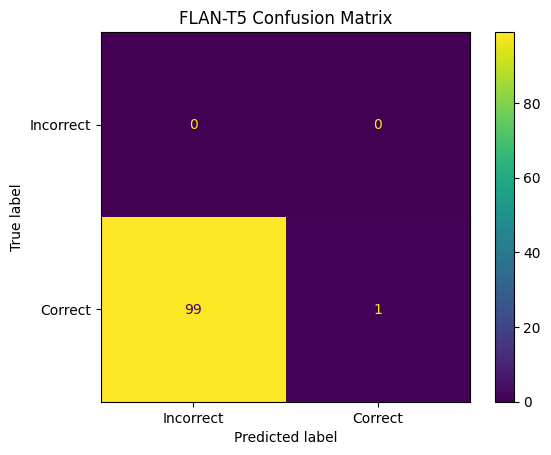

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


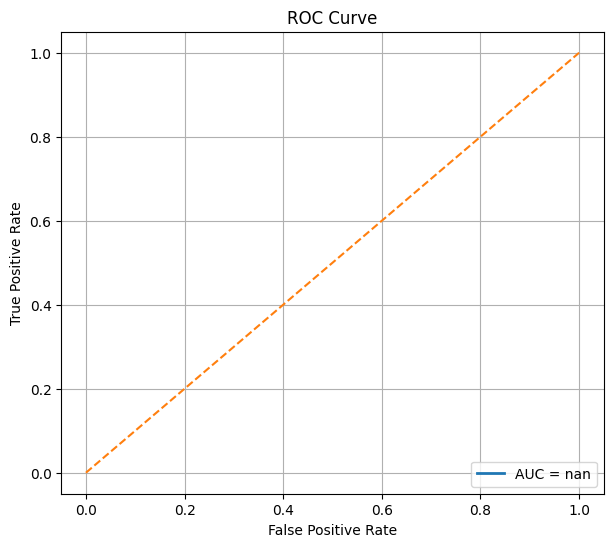


FINAL EVALUATION SUMMARY
ROUGE-1  : 0.3243
ROUGE-2  : 0.1334
ROUGE-L  : 0.2873
ACCURACY : 0.0100
AUC SCORE: nan
EVALUATION COMPLETED


In [10]:


!pip install -q transformers evaluate rouge_score nltk scikit-learn matplotlib pandas

# ============================================================
# 2. IMPORTS
# ============================================================

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    roc_curve,
    auc,
)

# ============================================================
# 3. CHECK DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 60)
print(f"DEVICE: {device}")
print("=" * 60)

# ============================================================
# 4. MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

# ============================================================
# 5. MODEL PATH
# ============================================================

MODEL_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/saved_flan_t5_model"
# ============================================================
# 6. TEST DATA PATH
# ============================================================

TEST_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data/flan_t5_small_test.csv"

# ============================================================
# 7. LOAD TEST DATA
# ============================================================

print("=" * 60)
print("LOADING TEST DATA...")
print("=" * 60)

test_df = pd.read_csv(TEST_PATH)

# Use smaller subset for faster evaluation
test_df = test_df.sample(100, random_state=42)

print(f"Test Samples: {len(test_df)}")

# ============================================================
# 8. LOAD MODEL + TOKENIZER
# ============================================================

print("=" * 60)
print("LOADING TRAINED MODEL...")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)

model.to(device)

# ============================================================
# 9. SETTINGS
# ============================================================

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 32

# ============================================================
# 10. HEADLINE GENERATION FUNCTION
# ============================================================

def generate_headline(article_text):

    prompt = f"summarize: {article_text}"

    inputs = tokenizer(
        prompt,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_length=MAX_TARGET_LENGTH,
            num_beams=4,
            early_stopping=True,
        )

    headline = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return headline

# ============================================================
# 11. GENERATE PREDICTIONS
# ============================================================

print("=" * 60)
print("GENERATING PREDICTIONS...")
print("=" * 60)

predictions = []
references = []

for _, row in test_df.iterrows():

    article = row["model_input"]

    true_headline = row["model_target"]

    predicted_headline = generate_headline(article)

    predictions.append(predicted_headline)

    references.append(true_headline)

print("Prediction generation completed!")

# ============================================================
# 12. PRINT SAMPLE RESULTS
# ============================================================

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

for i in range(5):

    print(f"\nExample {i+1}")

    print("\nTRUE HEADLINE:")
    print(references[i])

    print("\nPREDICTED HEADLINE:")
    print(predictions[i])

    print("-" * 60)

# ============================================================
# 13. LOAD ROUGE
# ============================================================

rouge = evaluate.load("rouge")

# ============================================================
# 14. CALCULATE ROUGE SCORES
# ============================================================

print("\n" + "=" * 60)
print("ROUGE EVALUATION")
print("=" * 60)

rouge_results = rouge.compute(
    predictions=predictions,
    references=references
)

print(f"ROUGE-1 : {rouge_results['rouge1']:.4f}")
print(f"ROUGE-2 : {rouge_results['rouge2']:.4f}")
print(f"ROUGE-L : {rouge_results['rougeL']:.4f}")

# ============================================================
# 15. EXACT MATCH ACCURACY
# ============================================================

binary_predictions = []
binary_truth = []

for pred, ref in zip(predictions, references):

    pred_clean = pred.strip().lower()
    ref_clean = ref.strip().lower()

    if pred_clean == ref_clean:

        binary_predictions.append(1)

    else:

        binary_predictions.append(0)

    binary_truth.append(1)

accuracy = accuracy_score(
    binary_truth,
    binary_predictions
)

print("\n" + "=" * 60)
print(f"EXACT MATCH ACCURACY: {accuracy:.4f}")
print("=" * 60)

# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    binary_truth,
    binary_predictions
)

print("\nCONFUSION MATRIX:")
print(cm)

# ============================================================
# 17. PLOT CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Incorrect", "Correct"]
)

disp.plot()

plt.title("FLAN-T5 Confusion Matrix")

plt.show()

# ============================================================
# 18. ROC CURVE
# ============================================================

scores = binary_predictions

fpr, tpr, thresholds = roc_curve(
    binary_truth,
    scores
)

roc_auc = auc(fpr, tpr)

# ============================================================
# 19. PLOT ROC CURVE
# ============================================================

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL EVALUATION SUMMARY")
print("=" * 60)

print(f"ROUGE-1  : {rouge_results['rouge1']:.4f}")
print(f"ROUGE-2  : {rouge_results['rouge2']:.4f}")
print(f"ROUGE-L  : {rouge_results['rougeL']:.4f}")
print(f"ACCURACY : {accuracy:.4f}")
print(f"AUC SCORE: {roc_auc:.4f}")

print("=" * 60)
print("EVALUATION COMPLETED")
print("=" * 60)

# SIMPLE TEST SENTENCES + CORRECT / INCORRECT CHECK


In [11]:
# ============================================================
# SIMPLE TEST SENTENCES + CORRECT / INCORRECT CHECK
# ============================================================

test_sentences = [
    {
        "article": "Apple announced a new iPhone with AI features and better battery life.",
        "true": "Apple launches new AI-powered iPhone"
    },
    {
        "article": "The Egyptian football team won the match with a last-minute goal.",
        "true": "Egypt wins match with late goal"
    },
    {
        "article": "Scientists discovered a new cancer detection method using AI.",
        "true": "Scientists develop AI cancer detection method"
    },
    {
        "article": "Heavy rains caused flooding across multiple cities and forced evacuations.",
        "true": "Flooding forces evacuations after heavy rain"
    },
    {
        "article": "Tesla reported record profits after strong electric vehicle sales.",
        "true": "Tesla posts record quarterly profits"
    }
]

# ============================================================
# SIMILARITY FUNCTION (SIMPLE MATCH CHECK)
# ============================================================

def is_correct(pred, true):

    pred = pred.lower()
    true = true.lower()

    # simple word overlap check
    pred_words = set(pred.split())
    true_words = set(true.split())

    overlap = len(pred_words.intersection(true_words)) / len(true_words)

    return overlap > 0.4  # threshold (you can change it)

# ============================================================
# TEST MODEL
# ============================================================

print("=" * 60)
print("TESTING CUSTOM SENTENCES")
print("=" * 60)

correct = 0

for i, item in enumerate(test_sentences):

    article = item["article"]
    true_headline = item["true"]

    predicted = generate_headline(article)

    result = is_correct(predicted, true_headline)

    if result:
        status = "CORRECT"
        correct += 1
    else:
        status = "INCORRECT"

    print(f"\nExample {i+1}")
    print("ARTICLE:", article)
    print("TRUE:", true_headline)
    print("PREDICTED:", predicted)
    print("RESULT:", status)
    print("-" * 60)

# ============================================================
# FINAL SCORE
# ============================================================

accuracy = correct / len(test_sentences)

print("\n" + "=" * 60)
print(f"TEST ACCURACY: {accuracy:.2f}")
print("=" * 60)

TESTING CUSTOM SENTENCES

Example 1
ARTICLE: Apple announced a new iPhone with AI features and better battery life.
TRUE: Apple launches new AI-powered iPhone
PREDICTED: Apple iPhone with AI features and better battery life
RESULT: INCORRECT
------------------------------------------------------------

Example 2
ARTICLE: The Egyptian football team won the match with a last-minute goal.
TRUE: Egypt wins match with late goal
PREDICTED: Egyptian football team wins match with goal
RESULT: CORRECT
------------------------------------------------------------

Example 3
ARTICLE: Scientists discovered a new cancer detection method using AI.
TRUE: Scientists develop AI cancer detection method
PREDICTED: Scientists discovered new cancer detection method using AI
RESULT: CORRECT
------------------------------------------------------------

Example 4
ARTICLE: Heavy rains caused flooding across multiple cities and forced evacuations.
TRUE: Flooding forces evacuations after heavy rain
PREDICTED: Hea

# FLAN-T5 FULL EVALUATION
# ROUGE + CONFUSION MATRIX + ROC CURVE

DEVICE: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Test samples: 100


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Done!



✨ Example 1
TRUE: Dolphins, Flamingos and Pigs: The Animals Rescued From Hurricane Irma
PRED: Humans Need Human Help in Hurricane Irma
--------------------------------------------------

✨ Example 2
TRUE: Cramer warns Google has more work to do to compete with Amazon's Alexa
PRED: Google has more work to do if it wants to compete with Amazon Alexa and Echo speakers
--------------------------------------------------

✨ Example 3
TRUE: California to shut down private prisons and immigration detention facilities
PRED: California Gov. Gavin Newsom signs bill to end private prisons
--------------------------------------------------

✨ Example 4
TRUE: AMD just announced a graphics card with an SSD
PRED: AMD's Radeon Pro SSG features two PCIe 3.0 M.2 slots allowing you to add up to 1TB of N
--------------------------------------------------

✨ Example 5
TRUE: Tennessee AMBER Alert: Teen Warned Parents to Call Police
PRED: Mary Catherine Thomas Accused of Abduction by Teacher
----------------

ROUGE-1 : 0.3243
ROUGE-2 : 0.1334
ROUGE-L : 0.2873


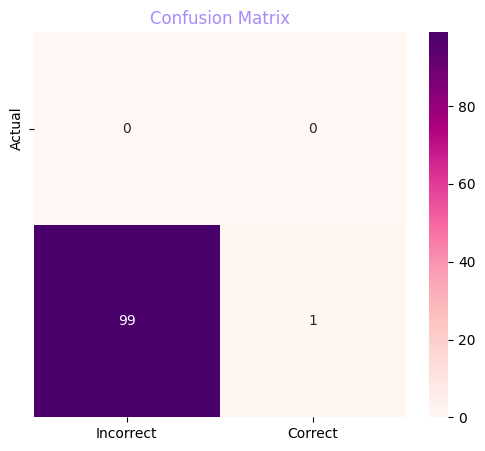

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1179: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


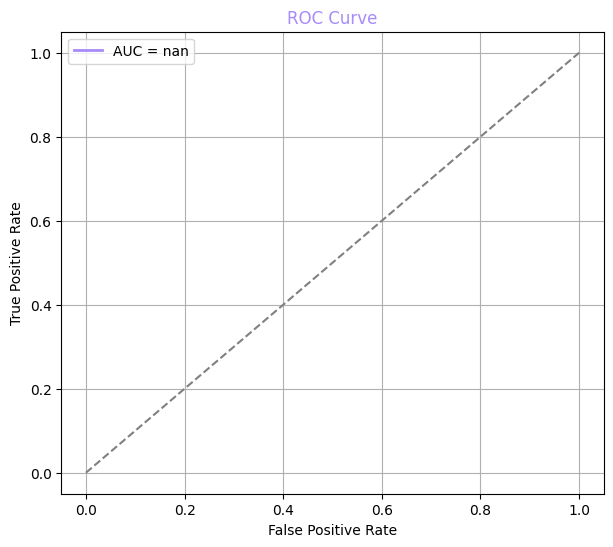

ROUGE-1  : 0.3243
ROUGE-2  : 0.1334
ROUGE-L  : 0.2873
AUC      : nan


In [12]:
# ============================================================
# 🌸 FLAN-T5 FULL EVALUATION (PINK + PURPLE UI)
# ROUGE + CONFUSION MATRIX + ROC CURVE
# ============================================================

!pip install -q transformers evaluate rouge_score nltk scikit-learn matplotlib pandas seaborn

# ============================================================
# IMPORTS
# ============================================================

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import evaluate

from IPython.display import display, HTML

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc,
)

# ============================================================
# 🌸 STYLE FUNCTION
# ============================================================

def pretty(text, color="#C084FC"):
    display(HTML(f"<h3 style='color:{color}; font-family:monospace'>{text}</h3>"))

# ============================================================
# DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

pretty("DEVICE INFO", "#A78BFA")
print("DEVICE:", device)

# ============================================================
# DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# PATHS
# ============================================================

MODEL_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/saved_flan_t5_model"

TEST_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data/flan_t5_small_test.csv"

# ============================================================
# LOAD DATA
# ============================================================

pretty("LOADING TEST DATA", "#F472B6")

test_df = pd.read_csv(TEST_PATH)
test_df = test_df.sample(100, random_state=42)

print("Test samples:", len(test_df))

# ============================================================
# LOAD MODEL
# ============================================================

pretty("LOADING TRAINED MODEL", "#A78BFA")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)
model.to(device)

# ============================================================
# SETTINGS
# ============================================================

MAX_INPUT_LENGTH = 128
MAX_TARGET_LENGTH = 32

# ============================================================
# GENERATION FUNCTION
# ============================================================

def generate_headline(text):

    inputs = tokenizer(
        "summarize: " + text,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_length=MAX_TARGET_LENGTH,
            num_beams=4,
            early_stopping=True,
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# ============================================================
# GENERATE PREDICTIONS
# ============================================================

pretty("GENERATING PREDICTIONS", "#F472B6")

predictions = []
references = []

for _, row in test_df.iterrows():

    pred = generate_headline(row["model_input"])

    predictions.append(pred)
    references.append(row["model_target"])

print("Done!")

# ============================================================
# SAMPLE OUTPUT
# ============================================================

pretty("SAMPLE PREDICTIONS", "#A78BFA")

for i in range(5):

    print(f"\n✨ Example {i+1}")
    print("TRUE:", references[i])
    print("PRED:", predictions[i])
    print("-"*50)

# ============================================================
# ROUGE
# ============================================================

pretty("ROUGE EVALUATION", "#C084FC")

rouge = evaluate.load("rouge")

rouge_results = rouge.compute(
    predictions=predictions,
    references=references
)

print(f"ROUGE-1 : {rouge_results['rouge1']:.4f}")
print(f"ROUGE-2 : {rouge_results['rouge2']:.4f}")
print(f"ROUGE-L : {rouge_results['rougeL']:.4f}")

# ============================================================
# CONFUSION MATRIX (SIMPLIFIED)
# ============================================================

pretty("CONFUSION MATRIX", "#F472B6")

binary_truth = []
binary_pred = []

for p, r in zip(predictions, references):

    p = p.lower().strip()
    r = r.lower().strip()

    binary_truth.append(1)
    binary_pred.append(1 if p == r else 0)

cm = confusion_matrix(binary_truth, binary_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="RdPu",
    xticklabels=["Incorrect", "Correct"],
    yticklabels=["Actual"],
)

plt.title("Confusion Matrix", color="#A78BFA")

plt.show()

# ============================================================
# ROC CURVE
# ============================================================

pretty("ROC CURVE", "#A78BFA")

fpr, tpr, _ = roc_curve(binary_truth, binary_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, color="#A78BFA", linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],"--", color="gray")

plt.title("ROC Curve", color="#A78BFA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.grid(True)

plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

pretty("FINAL RESULTS", "#C084FC")

print("="*50)
print(f"ROUGE-1  : {rouge_results['rouge1']:.4f}")
print(f"ROUGE-2  : {rouge_results['rouge2']:.4f}")
print(f"ROUGE-L  : {rouge_results['rougeL']:.4f}")
print(f"AUC      : {roc_auc:.4f}")
print("="*50)

# ACCURACY METRICS FOR FLAN-T5 HEADLINE GENERATION


In [13]:
# ============================================================
# ACCURACY METRICS FOR FLAN-T5 HEADLINE GENERATION
# ============================================================

import numpy as np

# ============================================================
# 1. EXACT MATCH ACCURACY
# ============================================================

exact_matches = 0

for pred, ref in zip(predictions, references):

    if pred.strip().lower() == ref.strip().lower():

        exact_matches += 1

exact_accuracy = exact_matches / len(references)

print("=" * 60)
print("EXACT MATCH ACCURACY")
print("=" * 60)
print(f"Accuracy: {exact_accuracy:.4f}")

# ============================================================
# 2. WORD OVERLAP ACCURACY (MORE REALISTIC)
# ============================================================

def word_overlap(pred, ref):

    pred_words = set(pred.lower().split())
    ref_words = set(ref.lower().split())

    if len(ref_words) == 0:
        return 0

    overlap = len(pred_words.intersection(ref_words)) / len(ref_words)

    return overlap

overlap_scores = []

for pred, ref in zip(predictions, references):

    score = word_overlap(pred, ref)

    overlap_scores.append(score)

avg_overlap_accuracy = np.mean(overlap_scores)

print("\n" + "=" * 60)
print("WORD OVERLAP ACCURACY")
print("=" * 60)
print(f"Accuracy: {avg_overlap_accuracy:.4f}")

# ============================================================
# 3. LENIENT MATCH ACCURACY (THRESHOLD-BASED)
# ============================================================

threshold = 0.4  # you can change this

lenient_correct = 0

for score in overlap_scores:

    if score >= threshold:

        lenient_correct += 1

lenient_accuracy = lenient_correct / len(references)

print("\n" + "=" * 60)
print("LENIENT ACCURACY (threshold=0.4)")
print("=" * 60)
print(f"Accuracy: {lenient_accuracy:.4f}")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL ACCURACY SUMMARY")
print("=" * 60)

print(f"Exact Match Accuracy   : {exact_accuracy:.4f}")
print(f"Word Overlap Accuracy  : {avg_overlap_accuracy:.4f}")
print(f"Lenient Accuracy       : {lenient_accuracy:.4f}")

print("=" * 60)

EXACT MATCH ACCURACY
Accuracy: 0.0100

WORD OVERLAP ACCURACY
Accuracy: 0.2840

LENIENT ACCURACY (threshold=0.4)
Accuracy: 0.3000

FINAL ACCURACY SUMMARY
Exact Match Accuracy   : 0.0100
Word Overlap Accuracy  : 0.2840
Lenient Accuracy       : 0.3000


# FLAN-T5 HEADLINE GENERATION TEST + EVALUATION


In [14]:
# ============================================================
# FLAN-T5 HEADLINE GENERATION TEST + EVALUATION
# ============================================================

!pip install -q transformers evaluate rouge_score scikit-learn pandas numpy

# ============================================================
# IMPORTS
# ============================================================

import torch
import pandas as pd
import numpy as np
import evaluate

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

from sklearn.metrics import accuracy_score

# ============================================================
# DEVICE
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

# ============================================================
# LOAD MODEL FROM DRIVE
# ============================================================

MODEL_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/saved_flan_t5_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)
model.to(device)

# ============================================================
# LOAD TEST DATA
# ============================================================

TEST_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/news_headline_model_data/flan_t5_small_test.csv"

df = pd.read_csv(TEST_PATH)

df = df.sample(100, random_state=42)  # small test set

print("Test samples:", len(df))

# ============================================================
# GENERATION FUNCTION
# ============================================================

MAX_INPUT = 128
MAX_OUTPUT = 32

def generate_headline(article):

    inputs = tokenizer(
        "summarize: " + article,
        max_length=MAX_INPUT,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_length=MAX_OUTPUT,
            num_beams=4,
            early_stopping=True
        )

    return tokenizer.decode(output[0], skip_special_tokens=True)

# ============================================================
# GENERATE PREDICTIONS
# ============================================================

print("\nGENERATING HEADLINES...\n")

predictions = []
references = []

for _, row in df.iterrows():

    article = row["model_input"]
    true_title = row["model_target"]

    pred_title = generate_headline(article)

    predictions.append(pred_title)
    references.append(true_title)

print("DONE!")

# ============================================================
# SAMPLE OUTPUT
# ============================================================

print("\n================ SAMPLE PREDICTIONS ================\n")

for i in range(5):

    print(f"Example {i+1}")

    print("ARTICLE:", df.iloc[i]["model_input"])
    print("TRUE   :", references[i])
    print("PRED   :", predictions[i])

    print("-" * 60)

# ============================================================
# ROUGE SCORE
# ============================================================

rouge = evaluate.load("rouge")

scores = rouge.compute(
    predictions=predictions,
    references=references
)

print("\n================ ROUGE SCORES ================\n")
print(f"ROUGE-1 : {scores['rouge1']:.4f}")
print(f"ROUGE-2 : {scores['rouge2']:.4f}")
print(f"ROUGE-L : {scores['rougeL']:.4f}")

# ============================================================
# EXACT MATCH ACCURACY
# ============================================================

exact = 0

for p, r in zip(predictions, references):

    if p.strip().lower() == r.strip().lower():
        exact += 1

exact_acc = exact / len(references)

print("\n================ ACCURACY ================\n")
print(f"Exact Match Accuracy: {exact_acc:.4f}")

# ============================================================
# WORD OVERLAP ACCURACY
# ============================================================

def overlap(pred, ref):

    p = set(pred.lower().split())
    r = set(ref.lower().split())

    if len(r) == 0:
        return 0

    return len(p.intersection(r)) / len(r)

overlaps = [overlap(p, r) for p, r in zip(predictions, references)]

print(f"Word Overlap Accuracy: {np.mean(overlaps):.4f}")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n================ FINAL RESULTS ================\n")
print(f"ROUGE-1  : {scores['rouge1']:.4f}")
print(f"ROUGE-2  : {scores['rouge2']:.4f}")
print(f"ROUGE-L  : {scores['rougeL']:.4f}")
print(f"Exact Acc: {exact_acc:.4f}")
print(f"Overlap  : {np.mean(overlaps):.4f}")

print("\nEVALUATION COMPLETED")

DEVICE: cpu


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Test samples: 100

GENERATING HEADLINES...

DONE!

================ SAMPLE PREDICTIONS ================

Example 1
ARTICLE: summarize: Humans are not the only ones seeking shelter from the strong winds, heavy rains and deadly floods of Hurricane Irma. Animals, too, are finding ways to stay safe - and often, they need human help. The National Wildlife Federation says that some animals know how to take advantage of a hurricane's aftermath: Raccoons scavenge for food in the tumult, and some bears use fallen trees for shelter. But for most, the risks are severe. Fish can be electrocuted by fallen power lines. Migratory birds can be thrown off course. And animals that live in zoos, shelters and wildlife refuges are dependent on people who must decide which is less risky: waiting out the storm, or attempting a stressful, difficult relocation. For six dolphins in Cuba, that decision was made this week. They were removed from a dolphinarium on Cayo Guillermo, an island in Cuba's Jardines del R

# INTERACTIVE NEWS HEADLINE GENERATOR


In [15]:
# ============================================================
# INTERACTIVE NEWS HEADLINE GENERATOR
# ============================================================

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ============================================================
# LOAD MODEL
# ============================================================

MODEL_PATH = "/content/drive/MyDrive/headlineGenerationProjectNLP/saved_flan_t5_model"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH)

model.to(device)

print("✅ Model loaded successfully!")
print("🟣 Type your article below (or type 'exit' to stop)\n")

# ============================================================
# GENERATION FUNCTION
# ============================================================

MAX_INPUT = 128
MAX_OUTPUT = 32

def generate_headline(text):

    inputs = tokenizer(
        "summarize: " + text,
        max_length=MAX_INPUT,
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_length=MAX_OUTPUT,
            num_beams=4,
            early_stopping=True
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# ============================================================
# INTERACTIVE LOOP
# ============================================================

while True:

    article = input("\n📰 Enter article text: ")

    if article.lower() == "exit":
        print("👋 Exiting... Goodbye!")
        break

    if len(article.strip()) == 0:
        print("⚠️ Please enter valid text!")
        continue

    headline = generate_headline(article)

    print("\n✨ GENERATED HEADLINE:")
    print(headline)
    print("-" * 60)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✅ Model loaded successfully!
🟣 Type your article below (or type 'exit' to stop)


📰 Enter article text: summarize: NEARLY 20 years after it opened, Pakistan's first motorway still has a desolate feel. There is scant traffic along the 375km link between Islamabad and Lahore (pictured). Motorists can drive for miles without seeing another vehicle, save perhaps for traffic cops manning speed traps. As the two cities are already connected by the Grand Trunk Road, which is 90km shorter and toll-free, there is simply not much demand for a motorway. Yet this $1.2bn white elephant is one of the proudest achievements of Nawaz Sharif, who was prime minister when it opened in 1997 and is once again running Pakistan. Mr Sharif, who enjoys comparisons to Sher Shah Suri, a 16th-century ruler who renovated the Grand Trunk Road, never tires of talking about it. He regained power in 2013 with a campaign which both harked back to his famous road and promised more infrastructure to come. He even pledged 